In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.linear_model import Lasso 

In [4]:
df= pd.read_csv("../data/13_insurance.csv")

In [9]:
x = df.drop(columns=["charges"])
y = df["charges"]
x= pd.get_dummies(x,columns=["region"],drop_first=True,dtype=int)
x["sex"]=x["sex"].map({"female":1,"male":0})
x["smoker"]=x["smoker"].map({"yes":1,"no":0})

x["age_smoker"]= x["age"]* x["smoker"]
x["bmi_smoker"]=x["bmi"]* x["smoker"]
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

mse for alpha (a) 20921803.698431384
mse for alpha (a) 20922599.871035974
mse for alpha (a) 20914832.635089148
mse for alpha (a) 20908106.779954527
mse for alpha (a) 20901927.931570236
mse for alpha (a) 20896130.81113566
mse for alpha (a) 20890881.000633504
mse for alpha (a) 21130888.630862623
mse for alpha (a) 20999628.39243299
mse for alpha (a) 21130888.630862623
mse for alpha (a) 21331288.608060267
mse for alpha (a) 21590784.139703363
mse for alpha (a) 21564762.740400013
mse for alpha (a) 22423172.68602322
mse for alpha (a) 20918648.88982562


<Axes: >

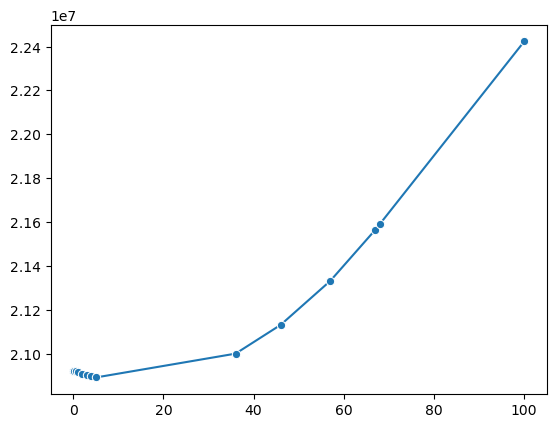

In [10]:
import seaborn as sns
alphas=[0.1,0.001,1,2,3,4,5,46,36,46,57,68,67,100,0.5]
mses=[]
for a in alphas:

    lasso_model= Lasso(alpha=a)
    lasso_model.fit(X_train,y_train)
    y_pred=lasso_model.predict(X_test)
    mse=mean_squared_error(y_test,y_pred)
    print(f"mse for alpha (a)" ,mse)
    mses.append(mse)
sns.lineplot(x=alphas,y=mses,marker="o")    

In [ ]:
from sklearn.linear_model import LassoCV
a= [0.001,0.05,0.1,1,2,5,10,20,30,50,100]

lasso_cv_model=LassoCV(
    alphas = a,
    cv = 5,
    max_iter = 1000,
    random_state = 42
)
lasso_cv_model.fit(X_train,y_train)
print("best alpha: ",lasso_cv_model.alpha_)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("mse = ",mse)
print("r2 = ", r2 )

best alpha:  0.001
mse =  20918648.88982562
s2 =  0.8652571992774442
